In [1]:
import duckdb
import pandas as pd
from pathlib import Path
import numpy as np

class DataHubReader:
    def __init__(self, db_name="silver_company.db"):
        """
        Stellt Verbindung zur DuckDB her.
        Erwartet dieselbe Ordnerstruktur wie DataHub.
        """
        base_path = Path.cwd()
        db_path = base_path.parent.parent / "data"  / db_name

        if not db_path.exists():
            raise FileNotFoundError(f"Datenbank nicht gefunden: {db_path}")
        self.con = duckdb.connect(str(db_path))

    def _fetch_table(self, table_name: str) -> pd.DataFrame:
        """Generische Methode zum Laden einer Tabelle."""
        return self.con.execute(f"SELECT * FROM {table_name}").df()
    def sql_command(self, command):
        return self.con.execute(f'{command}').df()
    def get_prices(self):
        return self.con.execute(f'Select * from observations').df()
    def close(self):
        """Schließt die Datenbankverbindung."""
        self.con.close()

In [12]:
hub = DataHubReader()
data = hub.sql_command("Select * from observations")
hub.close()
data = data.sort_values('EntityID')

In [34]:
ohlvc = ['Close', 'Open', 'High', 'Low', 'Volume']
data[~data['ItemName'].isin(ohlvc)].isna().sum()
data[data['Unit'].isna()]
tsla = data[data['EntityCode'] == 'ALV']
tsla[tsla['ItemName'] == 'TotalAssets'].sort_values('Date')
funda = data[~data['ItemName'].isin(ohlvc)]

In [40]:
funda[(funda['Date'] < '2022-01-01') & (funda['Value'].notna())]

,ObservationID,EntityID,ItemID,Date,Value,Unit,EntityCode,ItemName
8971300,14299,1,305,2021-12-31,4.873319e+08,USD,0001.HK,RestructuringAndMergernAcquisition
8971240,14239,1,189,2021-12-31,4.506538e+08,USD,0001.HK,NetForeignCurrencyExchangeGainLoss
8971239,14238,1,187,2021-12-31,-1.588959e+08,USD,0001.HK,NetCommonStockIssuance
8971255,14254,1,301,2021-12-31,-1.588959e+08,USD,0001.HK,RepurchaseOfCapitalStock
8971102,14083,1,354,2021-05-18,2.188950e-01,USD,0001.HK,dividends
...,...,...,...,...,...,...,...,...
2416276,9471637,8192,177,2021-12-31,-1.700000e+04,USD,ZYME,LongTermDebtPayments
2416283,9471644,8192,205,2021-12-31,-1.700000e+04,USD,ZYME,NetLongTermDebtIssuance
2416293,9471654,8192,300,2021-12-31,-1.700000e+04,USD,ZYME,RepaymentOfDebt
2416288,9471649,8192,250,2021-12-31,2.130000e+05,USD,ZYME,OtherNonCashItems


In [14]:
# Wie viele einzigartige Firmen haben jedes Feature?
total_companies = data["EntityCode"].nunique()

coverage = (
    data.groupby("ItemName")["EntityCode"]
    .nunique()
    .reset_index()
    .rename(columns={"EntityCode": "company_count"})
)
coverage["coverage_pct"] = coverage["company_count"] / total_companies * 100
coverage = coverage.sort_values("coverage_pct", ascending=False)

print(f"Gesamt Firmen: {total_companies}")
print(coverage)

Gesamt Firmen: 8192
                                              ItemName  company_count  \
56                                               Close           8189   
349                                             Volume           8189   
136                                               High           8189   
180                                                Low           8189   
228                                               Open           8189   
358                                 shares_outstanding           8125   
331                   TotalEquityGrossMinorityInterest           8116   
328                                        TotalAssets           8115   
333                TotalLiabilitiesNetMinorityInterest           8113   
60                                   CommonStockEquity           8113   
322                            TaxEffectOfUnusualItems           8112   
320                                 StockholdersEquity           8112   
213                            

In [15]:
# Nur Features die bei mind. 70% aller Firmen vorhanden sind
min_coverage = 0.70
core_features = coverage[coverage["coverage_pct"] >= min_coverage * 100]["ItemName"].tolist()

print(f"Features mit ≥70% Abdeckung: {len(core_features)}")
print(core_features)

Features mit ≥70% Abdeckung: 118
['Close', 'Volume', 'High', 'Low', 'Open', 'shares_outstanding', 'TotalEquityGrossMinorityInterest', 'TotalAssets', 'TotalLiabilitiesNetMinorityInterest', 'CommonStockEquity', 'TaxEffectOfUnusualItems', 'StockholdersEquity', 'NetTangibleAssets', 'TaxRateForCalcs', 'TangibleBookValue', 'NetIncomeFromContinuingOperationNetMinorityInterest', 'NormalizedIncome', 'TotalRevenue', 'NetIncomeFromContinuingAndDiscontinuedOperation', 'NetIncomeCommonStockholders', 'OrdinarySharesNumber', 'NetIncomeIncludingNoncontrollingInterests', 'NetIncome', 'OperatingRevenue', 'ShareIssued', 'NetIncomeContinuousOperations', 'PretaxIncome', 'CashAndCashEquivalents', 'CapitalStock', 'CommonStock', 'BasicEPS', 'DilutedEPS', 'DilutedAverageShares', 'BasicAverageShares', 'insidersPercentHeld', 'institutionsCount', 'institutionsPercentHeld', 'institutionsFloatPercentHeld', 'InvestedCapital', 'TotalCapitalization', 'DilutedNIAvailtoComStockholders', 'NetInterestIncome', 'FreeCashFlo

In [16]:
# Wie viele Jahre hat jede Firma pro Feature?
yearly_coverage = (
    data.assign(Year=pd.to_datetime(data["Date"]).dt.year)
    .groupby(["EntityCode", "ItemName"])["Year"]
    .nunique()
    .reset_index()
    .rename(columns={"Year": "year_count"})
)

# Nur Firmen+Feature Kombinationen mit mind. 3 Jahren
min_years = 3
sufficient = yearly_coverage[yearly_coverage["year_count"] >= min_years]

In [22]:
sufficient

,EntityCode,ItemName,year_count
0,0001.HK,AccountsPayable,5
1,0001.HK,AccountsReceivable,5
2,0001.HK,AccumulatedDepreciation,5
3,0001.HK,AdditionalPaidInCapital,5
4,0001.HK,AllowanceForDoubtfulAccountsReceivable,5
...,...,...,...
1388331,ZYME,TotalUnusualItemsExcludingGoodwill,5
1388332,ZYME,UnrealizedGainLossOnInvestmentSecurities,5
1388333,ZYME,Volume,6
1388334,ZYME,WorkingCapital,5


In [17]:
# Firmen die alle Core-Features mit mind. min_years haben
sufficient_core = sufficient[sufficient["ItemName"].isin(core_features)]

# Wie viele Core-Features hat jede Firma?
company_feature_count = (
    sufficient_core.groupby("EntityCode")["ItemName"]
    .nunique()
    .reset_index()
    .rename(columns={"ItemName": "feature_count"})
)

# Firmen die ALLE Core-Features haben
complete_companies = company_feature_count[
    company_feature_count["feature_count"] == len(core_features)
]["EntityCode"].tolist()

print(f"Firmen mit vollständigen Daten: {len(complete_companies)}")

Firmen mit vollständigen Daten: 0


In [18]:
data_clean = data[
    (data["EntityCode"].isin(complete_companies)) &
    (data["ItemName"].isin(core_features))
].copy()

print(f"Shape: {data_clean.shape}")
print(f"Firmen: {data_clean['EntityCode'].nunique()}")
print(f"Features: {data_clean['ItemName'].nunique()}")

Shape: (0, 8)
Firmen: 0
Features: 0


Core Features: 118
count    8084.000000
mean      103.143617
std        15.421836
min         1.000000
25%       103.000000
50%       108.000000
75%       111.000000
max       114.000000
Name: feature_count, dtype: float64


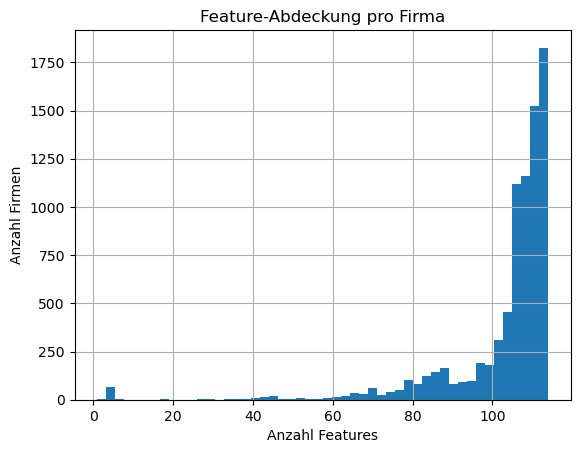

Max Features einer Firma: 114
Top 10 Firmen nach Feature-Abdeckung:
     EntityCode  feature_count
2059    3800.HK            114
1483    2013.HK            114
433     0563.HK            114
7656     UBI.PA            114
6959     RXL.PA            114
2882       ALTI            114
3767       COKE            114
424     0551.HK            114
1675    2333.HK            114
3134       AVAH            114


In [23]:
# 1. Wie viele Core-Features wurden gefunden?
print(f"Core Features: {len(core_features)}")

# 2. Verteilung – wie viele Features haben die Firmen im Durchschnitt?
print(company_feature_count["feature_count"].describe())

# 3. Wie sieht die Verteilung aus?
import matplotlib.pyplot as plt
company_feature_count["feature_count"].hist(bins=50)
plt.xlabel("Anzahl Features")
plt.ylabel("Anzahl Firmen")
plt.title("Feature-Abdeckung pro Firma")
plt.show()

# 4. Was ist das Maximum das eine Firma erreicht?
print(f"Max Features einer Firma: {company_feature_count['feature_count'].max()}")
print(f"Top 10 Firmen nach Feature-Abdeckung:")
print(company_feature_count.sort_values("feature_count", ascending=False).head(10))

In [24]:
# 1. Welche Core-Features erreichen nie 114+?
problematic_features = coverage[
    (coverage["ItemName"].isin(core_features)) &
    (coverage["company_count"] < total_companies * 0.75)  # unter 75%
].sort_values("coverage_pct")

print(problematic_features)

                          ItemName  company_count  coverage_pct
202   NetInvestmentPurchaseAndSale           5774     70.483398
67   CurrentCapitalLeaseObligation           5853     71.447754
144     InterestIncomeNonOperating           5937     72.473145
340                TotalTaxPayable           5956     72.705078
83                    Depreciation           6128     74.804688


In [25]:
# Statt "alle 118" → mind. 110 von 114 erreichbaren Features
complete_companies = company_feature_count[
    company_feature_count["feature_count"] >= 110
]["EntityCode"].tolist()

print(f"Firmen mit ≥110 Features: {len(complete_companies)}")

# Oder prozentual vom tatsächlichen Maximum
max_features = company_feature_count["feature_count"].max()  # 114

complete_companies = company_feature_count[
    company_feature_count["feature_count"] >= max_features * 0.95
]["EntityCode"].tolist()

print(f"Firmen mit ≥95% des Maximums ({int(max_features * 0.95)} Features): {len(complete_companies)}")

Firmen mit ≥110 Features: 3351
Firmen mit ≥95% des Maximums (108 Features): 3970


In [26]:
for threshold in [114, 112, 110, 108, 105, 100]:
    n = (company_feature_count["feature_count"] >= threshold).sum()
    print(f"≥{threshold} Features: {n} Firmen ({n/len(company_feature_count)*100:.1f}%)")

≥114 Features: 390 Firmen (4.8%)
≥112 Features: 1826 Firmen (22.6%)
≥110 Features: 3351 Firmen (41.5%)
≥108 Features: 4511 Firmen (55.8%)
≥105 Features: 5629 Firmen (69.6%)
≥100 Features: 6492 Firmen (80.3%)


In [27]:
# Wie viele Jahre haben die Firmen bei verschiedenen Thresholds?
for threshold in [114, 112, 110, 108, 105]:
    companies = company_feature_count[
        company_feature_count["feature_count"] >= threshold
    ]["EntityCode"].tolist()
    
    years = (
        data[data["EntityCode"].isin(companies)]
        .assign(Year=pd.to_datetime(data["Date"]).dt.year)
        .groupby("EntityCode")["Year"]
        .nunique()
    )
    
    print(f"≥{threshold} Features: {len(companies)} Firmen | "
          f"Ø {years.mean():.1f} Jahre | "
          f"Min {years.min()} | "
          f"Median {years.median():.0f} Jahre")

≥114 Features: 390 Firmen | Ø 11.9 Jahre | Min 5 | Median 8 Jahre
≥112 Features: 1826 Firmen | Ø 11.6 Jahre | Min 4 | Median 7 Jahre
≥110 Features: 3351 Firmen | Ø 12.2 Jahre | Min 4 | Median 7 Jahre
≥108 Features: 4511 Firmen | Ø 12.3 Jahre | Min 4 | Median 7 Jahre
≥105 Features: 5629 Firmen | Ø 12.3 Jahre | Min 4 | Median 7 Jahre


In [33]:
min_features = 108
min_years = 4

# Firmen mit genug Features
companies_by_features = company_feature_count[
    company_feature_count["feature_count"] >= min_features
]["EntityCode"].tolist()

# Davon nur Firmen mit genug Jahren
years_per_company = (
    data[data["EntityCode"].isin(companies_by_features)]
    .assign(Year=pd.to_datetime(data["Date"]).dt.year)
    .groupby("EntityCode")["Year"]
    .nunique()
    .reset_index()
    .rename(columns={"Year": "year_count"})
)

final_companies = years_per_company[
    years_per_company["year_count"] >= min_years
]["EntityCode"].tolist()

print(f"Finale Firmen: {len(final_companies)}")

# Finales Dataset
data_clean = data[
    (data["EntityCode"].isin(final_companies)) &
    (data["ItemName"].isin(core_features))
].copy()

print(f"Shape: {data_clean.shape}")
print(f"Firmen: {data_clean['EntityCode'].nunique()}")
print(f"Features: {data_clean['ItemName'].nunique()}")

Finale Firmen: 4511
Shape: (4261925, 8)
Firmen: 4511
Features: 118
